# IMPORT THƯ VIỆN CẦN THIẾT 

In [34]:

from scipy.stats import chi2_contingency
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, r2_score
import itertools

In [35]:
# Hàm phân tích biến phân loại
from scipy.stats import chi2_contingency
from scipy import stats
def check_chi_square(df, col1, col2):
    """
    Hàm kiểm tra tính độc lập giữa 2 biến phân loại bằng Chi-Square.
    Nhằm phát hiện đa cộng tuyến phân loại.
    """
    # 1. Lập bảng tần suất chéo (Contingency Table) giữa 2 biến
    contingency_table = pd.crosstab(df[col1], df[col2])
    
    # 2. Chạy kiểm định Chi-Square
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table) # 
    
    # 3. In kết quả trực quan
    print(f"--- KIỂM ĐỊNH CHI-SQUARE: [{col1}] & [{col2}] ---")
    print(f"Giá trị thống kê χ² : {chi2_stat:.4f}")
    print(f"p-value             : {p_value:.4f}") # In ra p-value của kiểm định


def filter_by_anova_eta(df, cat_col, target_col): 
    """
    Sử dụng kiểm định ANOVA : ANOVA (Phân tích phương sai - Analysis of Variance) 
    là một phương pháp thống kê được sử dụng để kiểm tra xem có sự khác biệt có ý nghĩa thống kê giữa giá trị trung bình của 2, ba nhóm trở lên hay không. (Kiểm định với p-value)
    Giúp phân tích tác động của các biến phân loại (độc lập) lên một biến liên tục (phụ thuộc)
    
    và chỉ số Eta-squared (η²).
    """
    # Lọc bỏ các dòng có giá trị NaN ở 2 cột đang xét để hàm không bị lỗi
    valid_data = df[[cat_col, target_col]].dropna()
    
    # 1. CHUẨN BỊ DỮ LIỆU CHO ANOVA
    # Tách biến mục tiêu thành các mảng (arrays) riêng biệt theo từng nhóm phân loại
    groups = [group[target_col].values for name, group in valid_data.groupby(cat_col)]
    
    # 2. CHẠY KIỂM ĐỊNH ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    
    # 3. TÍNH TOÁN ETA-SQUARED (η²)
    # Tính trung bình của toàn bộ biến mục tiêu
    mean_total = valid_data[target_col].mean()
    
    # Tính Sum of Squares Total (SST)
    ss_total = ((valid_data[target_col] - mean_total) ** 2).sum()
    
    # Tính Sum of Squares Between (SSB)
    ss_between = 0
    for name, group in valid_data.groupby(cat_col):
        ss_between += len(group) * ((group[target_col].mean() - mean_total) ** 2)
        
    # Công thức Eta-squared
    eta_squared = ss_between / ss_total
    
    # 4. TRÌNH BÀY KẾT QUẢ
    print(f"--- ĐÁNH GIÁ BIẾN: [{cat_col}] tác động lên [{target_col}] ---")
    
    # In p-value (dùng định dạng số mũ e nếu quá nhỏ để tránh hiển thị 0.0000)

    print(f"p-value (ANOVA)  : {p_value:.4f} ")
    
    # In Eta-squared
    print(f"Eta-squared (η²) : {eta_squared:.4f}")

def filter_by_ttest(df, cat_col, target_col):
    """Trả về duy nhất giá trị p-value để kiểm định sự khác biệt giữa 2 nhóm."""
    # Lọc bỏ giá trị khuyết (NaN)
    valid_data = df[[cat_col, target_col]].dropna()

    # Lấy danh sách 2 nhãn của nhóm
    groups = valid_data[cat_col].unique()

    # Tách dữ liệu thành 2 mảng tương ứng với 2 nhóm
    group1 = valid_data[valid_data[cat_col] == groups[0]][target_col].values
    group2 = valid_data[valid_data[cat_col] == groups[1]][target_col].values

    # Chạy t-test độc lập (sử dụng Welch's t-test bằng cách đặt equal_var=False để an toàn)
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    print(f"p-value (T-test)  : {p_value:.4f} ")


In [36]:
df=pd.read_csv("Telco Customer Churn.csv")

In [37]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
df.shape

(7043, 21)

In [39]:
df.isnull().mean()

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [41]:
# Xóa cột customerID và cập nhật lại biến df
df = df.drop(columns=['customerID'])



# Biến đổi kiểu dữ liệu cho hợp lí 

In [42]:
import pandas as pd
import numpy as np

# 1. Ép kiểu TotalCharges từ Chuỗi sang Số
# Tham số errors='coerce' cực kỳ quyền lực: Nó sẽ ép các khoảng trắng " " thành giá trị khuyết NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


# Kiểm tra lại thành quả
print("--- KIỂM TRA LẠI KIỂU DỮ LIỆU ---")
print(df[[ 'TotalCharges']].dtypes)

--- KIỂM TRA LẠI KIỂU DỮ LIỆU ---
TotalCharges    float64
dtype: object


In [43]:
# 1. Quét và lọc ra danh sách các cột mang kiểu dữ liệu phân loại (chữ/object/category)
# Lưu ý: Cột SeniorCitizen sau khi được ép kiểu ở bước trước sẽ tự động lọt vào danh sách này
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Đếm số lượng
tong_so_cot = len(categorical_cols)

# 3. In kết quả báo cáo đẹp mắt
print("=" * 40)
print(f"BÁO CÁO: TỔNG KẾT BIẾN PHÂN LOẠI")
print("=" * 40)
print(f" {tong_so_cot} cột phân loại.\n")

print(" Danh sách chi tiết:")
print("-" * 40)
for i, col in enumerate(categorical_cols, 1):
    print(f"{i:02d}. {col}")

BÁO CÁO: TỔNG KẾT BIẾN PHÂN LOẠI
 16 cột phân loại.

 Danh sách chi tiết:
----------------------------------------
01. gender
02. Partner
03. Dependents
04. PhoneService
05. MultipleLines
06. InternetService
07. OnlineSecurity
08. OnlineBackup
09. DeviceProtection
10. TechSupport
11. StreamingTV
12. StreamingMovies
13. Contract
14. PaperlessBilling
15. PaymentMethod
16. Churn


C:\Users\Admin\AppData\Local\Temp\ipykernel_20156\2578109336.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


# Kiểm tra giá trị của từng biến phân loại 

In [44]:
# 1. Gom tất cả các cột phân loại (dạng chữ hoặc mã nhãn) vào một danh sách
categorical_cols_telco = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'PhoneService', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

# 2. Chạy vòng lặp để in tự động và trình bày đẹp mắt
print("="*50)
print("THỐNG KÊ TẦN SUẤT CÁC BIẾN PHÂN LOẠI")
print("="*50)

for col in categorical_cols_telco:
    print(f"\n Cột: [{col}]")
    print("-" * 30)
    print(df[col].value_counts())

THỐNG KÊ TẦN SUẤT CÁC BIẾN PHÂN LOẠI

 Cột: [gender]
------------------------------
gender
Male      3555
Female    3488
Name: count, dtype: int64

 Cột: [SeniorCitizen]
------------------------------
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

 Cột: [Partner]
------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Cột: [Dependents]
------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 Cột: [PhoneService]
------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 Cột: [MultipleLines]
------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 Cột: [InternetService]
------------------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 Cột: [OnlineSecurity]
------------------------------
OnlineSecurity
No      

# Phân tích biến liên tục 

--- 1. VẼ BIỂU ĐỒ PHÂN PHỐI (HISTOGRAM) ---


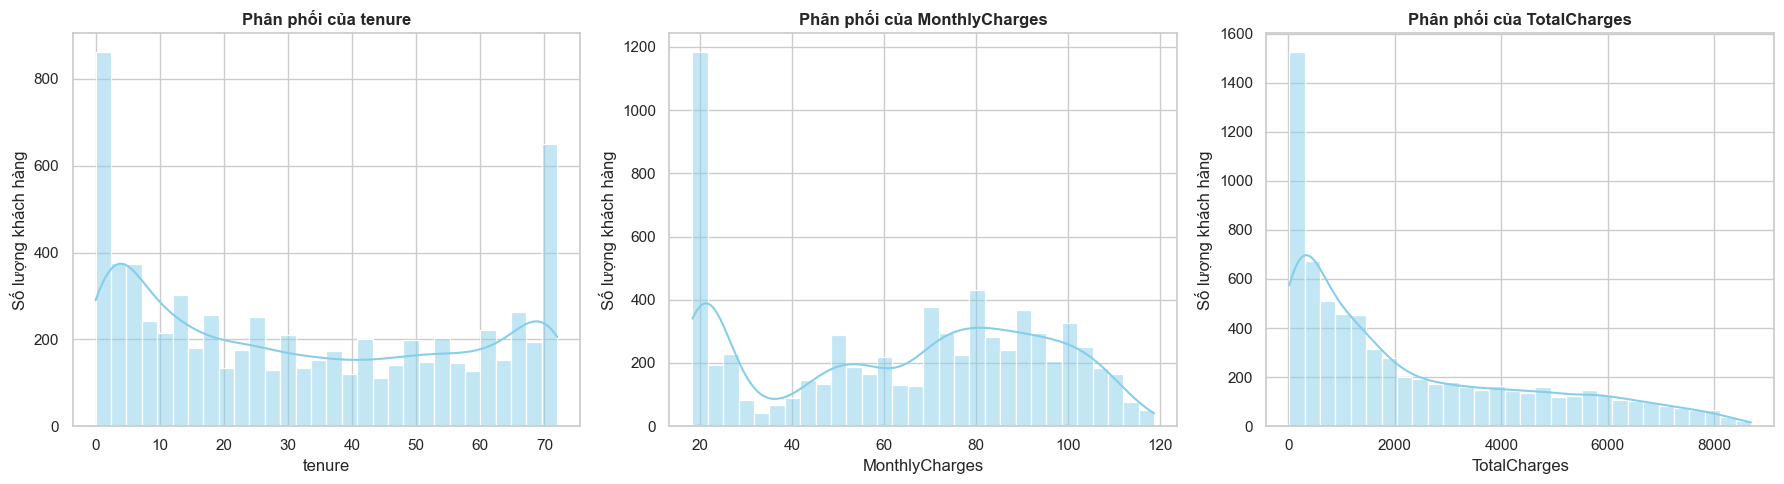


--- 2. VẼ BIỂU ĐỒ HỘP TÌM OUTLIERS (BOXPLOT) ---


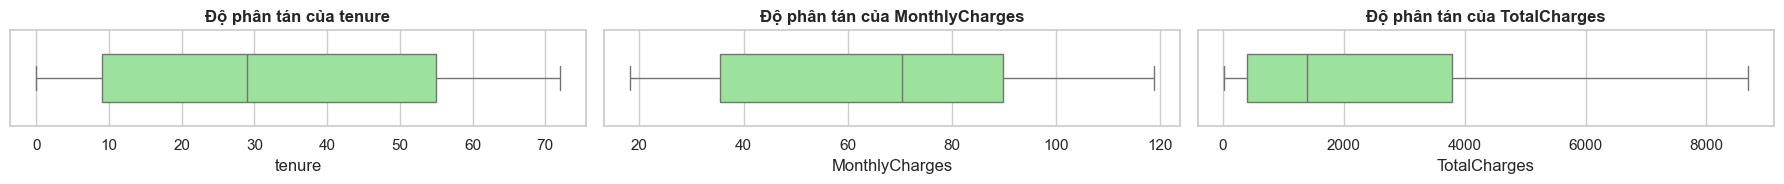


--- 3. KIỂM TRA TƯƠNG QUAN (CORRELATION HEATMAP) ---


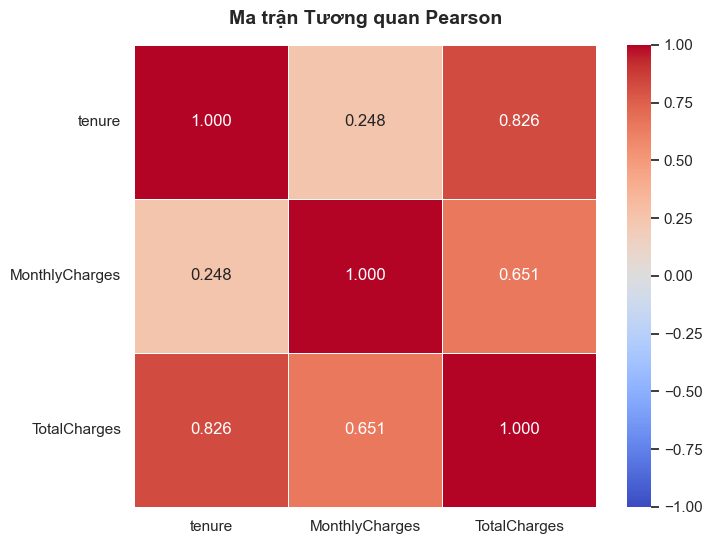

In [45]:

# Danh sách các biến liên tục cần phân tích
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Cài đặt giao diện Seaborn cho đẹp mắt
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# 1. PHÂN TÍCH PHÂN PHỐI DỮ LIỆU (HISTOGRAM)
# ==========================================
print("--- 1. VẼ BIỂU ĐỒ PHÂN PHỐI (HISTOGRAM) ---")
plt.figure(figsize=(18, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    # Vẽ histogram kèm đường cong KDE để nhìn rõ xu hướng
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối của {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Số lượng khách hàng')

plt.tight_layout()
plt.show()

# ==========================================
# 2. KIỂM TRA ĐIỂM DỊ BIỆT (BOXPLOT)
# ==========================================
print("\n--- 2. VẼ BIỂU ĐỒ HỘP TÌM OUTLIERS (BOXPLOT) ---")
plt.figure(figsize=(18, 2)) # Chiều cao ngắn lại vì boxplot nằm ngang
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col], color='lightgreen', width=0.5)
    plt.title(f'Độ phân tán của {col}', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 3. MA TRẬN TƯƠNG QUAN PEARSON (HEATMAP)
# ==========================================
print("\n--- 3. KIỂM TRA TƯƠNG QUAN (CORRELATION HEATMAP) ---")
plt.figure(figsize=(8, 6))

# Tính ma trận tương quan giữa 3 biến liên tục
corr_matrix = df[num_cols].corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", 
            vmin=-1, vmax=1, linewidths=0.5, square=True)

plt.title('Ma trận Tương quan Pearson', fontsize=14, fontweight='bold', pad=15)
plt.yticks(rotation=0)
plt.show()

- Tương quan của các biến với biển mục tiêu khá tốt 

# Trực quan từng cặp 

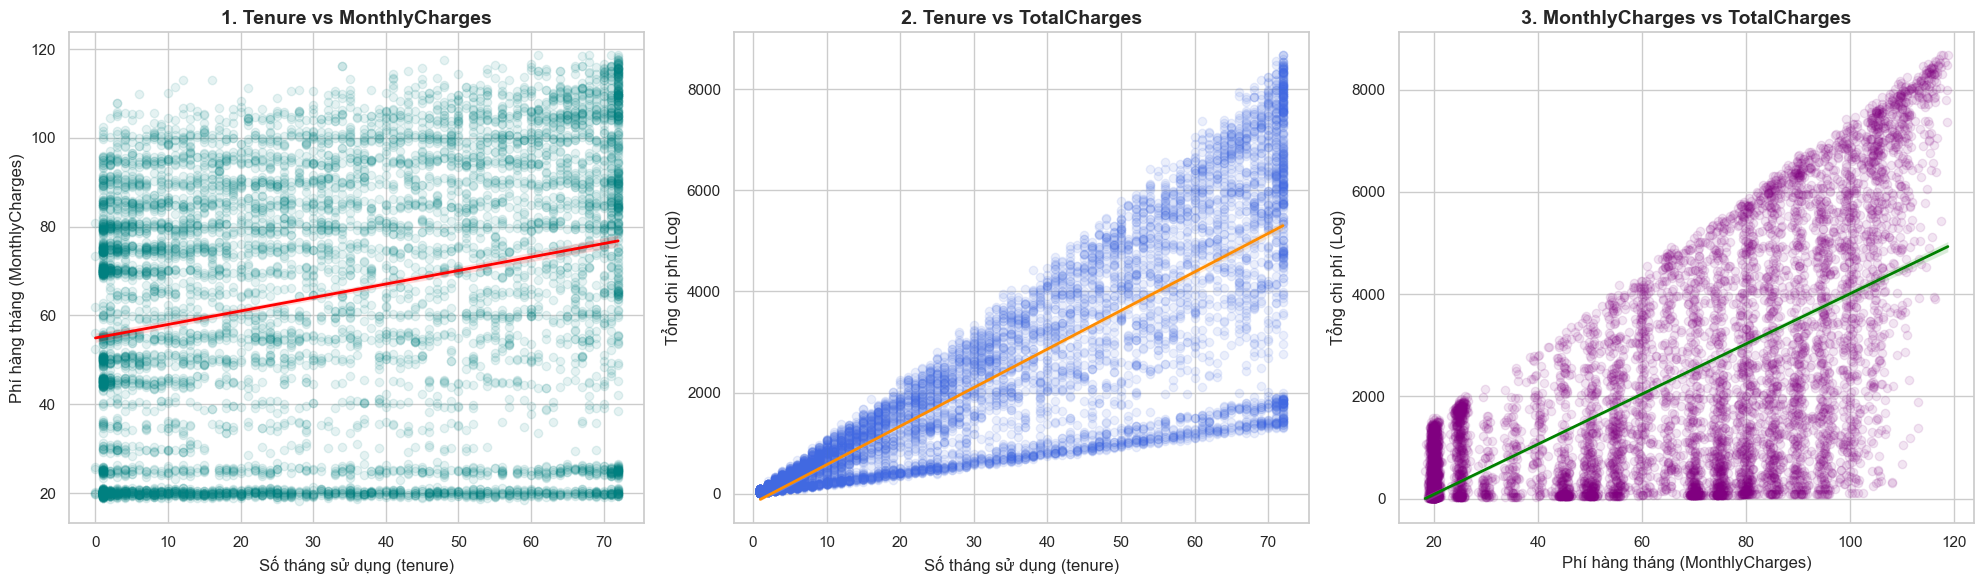

In [46]:

# Thiết lập giao diện nền trắng lưới mờ
sns.set_theme(style="whitegrid")

# Tạo một "bức tranh" lớn gồm 1 hàng và 3 cột, kích thước rộng 20, cao 6
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# =======================================================
# Ô số 1: Số tháng (tenure) vs Phí hàng tháng (MonthlyCharges)
# =======================================================
sns.regplot(data=df, x='tenure', y='MonthlyCharges', ax=axes[0],
            scatter_kws={'alpha': 0.1, 'color': 'teal'}, 
            line_kws={'color': 'red', 'linewidth': 2})
axes[0].set_title('1. Tenure vs MonthlyCharges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số tháng sử dụng (tenure)')
axes[0].set_ylabel('Phí hàng tháng (MonthlyCharges)')

# =======================================================
# Ô số 2: Số tháng (tenure) vs Tổng chi phí (TotalCharges)
# =======================================================
sns.regplot(data=df, x='tenure', y='TotalCharges', ax=axes[1],
            scatter_kws={'alpha': 0.1, 'color': 'royalblue'}, 
            line_kws={'color': 'darkorange', 'linewidth': 2})
axes[1].set_title('2. Tenure vs TotalCharges', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số tháng sử dụng (tenure)')
axes[1].set_ylabel('Tổng chi phí (Log)')

# =======================================================
# Ô số 3: Phí hàng tháng (MonthlyCharges) vs Tổng chi phí  (TotalCharges)
# =======================================================
sns.regplot(data=df, x='MonthlyCharges', y='TotalCharges', ax=axes[2],
            scatter_kws={'alpha': 0.1, 'color': 'purple'}, 
            line_kws={'color': 'green', 'linewidth': 2})
axes[2].set_title('3. MonthlyCharges vs TotalCharges', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Phí hàng tháng (MonthlyCharges)')
axes[2].set_ylabel('Tổng chi phí (Log)')

# Căn chỉnh tự động để chữ không bị đè lên nhau
plt.tight_layout()
plt.show()

# Tính VIF 

In [47]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Xác định danh sách các biến liên tục (X) và biến mục tiêu (Y)
# Sử dụng TotalCharges (hoặc TotalCharges) làm mục tiêu để loại bỏ ra khỏi tập X
df_continuous_features = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()  
X_ = df_continuous_features.drop(columns=['TotalCharges'])

# 2 & 3. Encode biến phân loại 
# Hiện tại tập X_ chỉ có biến liên tục, nhưng vẫn giữ form này để bạn dễ mở rộng sau này
# Ví dụ: Nếu sau này muốn kiểm tra VIF của cả hợp đồng (Contract), bạn chỉ cần mở comment
# X_encoded = pd.get_dummies(
#     X_,
#     columns=['Contract'],
#     drop_first=True,
#     dtype=int
# )
X_encoded = X_.copy()

# 4. BẮT BUỘC: Thêm cột hằng số (constant) để thuật toán tính VIF chính xác
X_with_const = sm.add_constant(X_encoded)

# 5. Tính toán chỉ số VIF cho từng đặc trưng
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i)
    for i in range(X_with_const.shape[1])
]

# In kết quả, làm tròn 4 chữ số thập phân
print("\n--- BÁO CÁO KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---")
print(vif_data.round(4))


--- BÁO CÁO KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---
          Feature     VIF
0           const  6.2888
1          tenure  1.0655
2  MonthlyCharges  1.0655


2 biến ko có hiện tượng đa cộng tuyến 

# Phân tích biến phân loại 

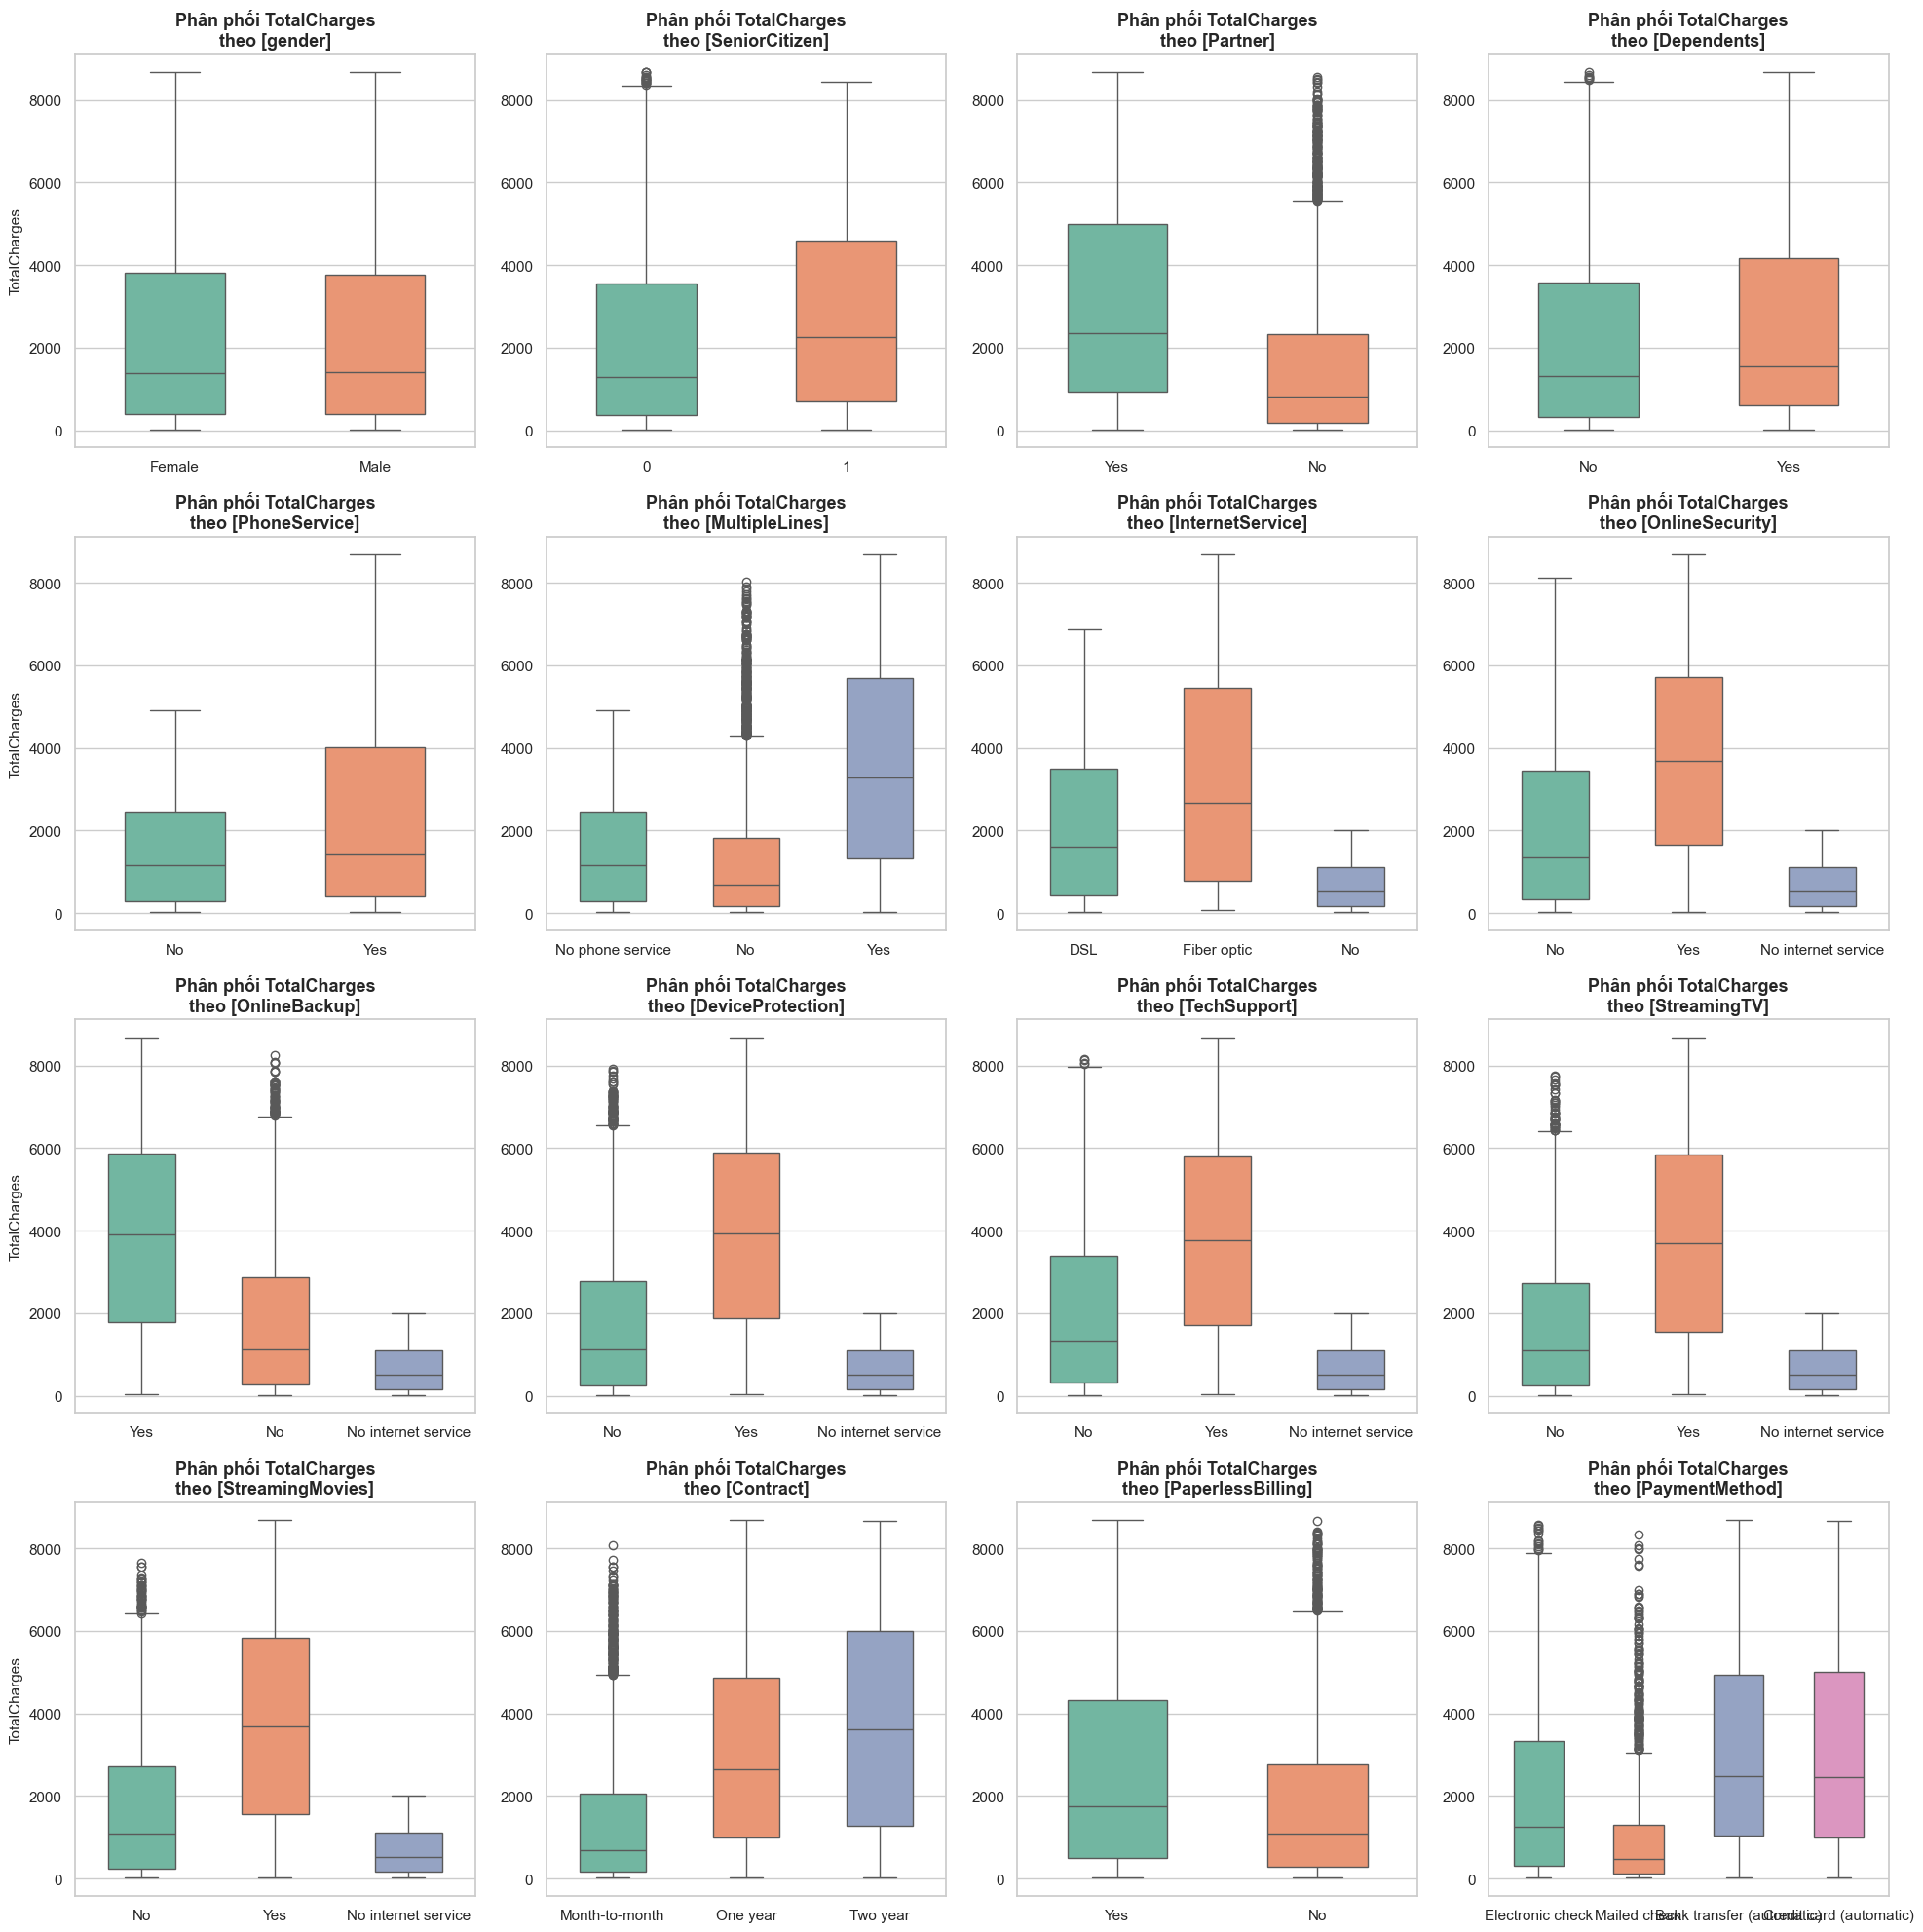

In [48]:

# ==========================================
# 1. CẤU HÌNH BIẾN MỤC TIÊU VÀ BIẾN PHÂN LOẠI
# ==========================================
target = 'TotalCharges'  # Ưu tiên dùng biến đã xử lý Logarit để Boxplot không bị méo

# Chọn ra các biến phân loại quan trọng muốn vẽ (Bạn có thể thêm bớt tùy ý)
cat_cols_telco = [
    # 1. Thông tin Nhân khẩu học (Demographics)
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    
    # 2. Dịch vụ Điện thoại (Phone Services)
    'PhoneService', 'MultipleLines', 
    
    # 3. Dịch vụ Internet & Tính năng bảo mật (Internet & Add-ons)
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    
    # 4. Thông tin Hợp đồng & Thanh toán (Billing & Contract)
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
# ==========================================
# 2. THUẬT TOÁN TỰ ĐỘNG CHIA LƯỚI (DYNAMIC GRID)
# ==========================================
n_features = len(cat_cols_telco)
n_cols_grid = 4  # Chốt cứng số cột ngang (4 biểu đồ trên 1 hàng cho dễ nhìn)

# Tự động làm tròn lên để tính số hàng cần thiết (Ví dụ: 8 biến / 4 = 2 hàng)
n_rows_grid = math.ceil(n_features / n_cols_grid) 

# ==========================================
# 3. VẼ VÀ TRANG TRÍ BIỂU ĐỒ
# ==========================================
sns.set_theme(style="whitegrid")

# Kích thước khung tự động giãn nở: Ngang 20, Cao bằng [Số hàng * 5]
plt.figure(figsize=(20, 5 * n_rows_grid)) 

for i, col in enumerate(cat_cols_telco, 1):
    # Khởi tạo từng ô con bằng lưới động đã tính ở trên
    ax = plt.subplot(n_rows_grid, n_cols_grid, i)
    
    # Vẽ Boxplot (thêm palette màu để tách biệt các nhóm dễ hơn)
    sns.boxplot(x=col, y=target, data=df, width=0.5, palette="Set2", hue=col, legend=False)
    
    # Trang trí biểu đồ con
    ax.set_title(f'Phân phối {target}\ntheo [{col}]', fontsize=13, fontweight='bold')
    ax.set_xlabel('') # Tạm ẩn tên trục X vì tiêu đề đã ghi rõ tên cột
    
    # Kỹ thuật ẩn trục Y thông minh: Chỉ hiện nhãn Y ở biểu đồ nằm ngoài cùng bên trái của mỗi hàng
    if i % n_cols_grid == 1:
        ax.set_ylabel(target, fontsize=11)
    else:
        ax.set_ylabel("")

# Tự động dàn đều để chữ không đè lên nhau
plt.tight_layout()
plt.show()

# Kiểm định 

# 2 biến 

In [49]:

def filter_by_welch_ttest_eta(df, binary_col, target_col):
    # 1. Làm sạch dữ liệu
    valid_data = df[[binary_col, target_col]].dropna()
    groups = valid_data[binary_col].unique()

    # 2. Tách dữ liệu thành 2 nhóm
    group1 = valid_data[valid_data[binary_col] == groups[0]][target_col].values
    group2 = valid_data[valid_data[binary_col] == groups[1]][target_col].values

    # 3. Chạy kiểm định Welch's T-test
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    # 4. TÍNH TOÁN ETA-SQUARED (Mức độ giải thích sự biến thiên)
    n1, n2 = len(group1), len(group2)
    df_degrees = n1 + n2 - 2
    eta_squared = (t_stat**2) / ((t_stat**2) + df_degrees)
    
    # Đổi ra phần trăm cho dễ đọc
    eta_pct = eta_squared * 100

    # 5. Kết luận dựa trên ngưỡng 0.05
    conclusion = " GIỮ LẠI" if p_value < 0.05 else "❌ LOẠI BỎ"

    # In báo cáo với Bảng xếp hạng sức mạnh
    print(f" T-TEST BIẾN: [{binary_col}]")
    print(f"   p-value      : {p_value:.6f}  ->  {conclusion}")
    print(f"   Eta-squared  : {eta_pct:.2f}% (Biến này quyết định {eta_pct:.2f}% tổng chi phí)")
    print("-" * 55)

# ==========================================
# CÁCH ÁP DỤNG VÀO BỘ DỮ LIỆU TELCO
# ==========================================
binary_cols_telco = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
target = 'TotalCharges'

print("=" * 55)
print("BÁO CÁO: XẾP HẠNG SỨC MẠNH BIẾN NHỊ PHÂN (KÈM ETA-SQUARED)")
print("=" * 55)

for col in binary_cols_telco:
    filter_by_welch_ttest_eta(df, col, target)

BÁO CÁO: XẾP HẠNG SỨC MẠNH BIẾN NHỊ PHÂN (KÈM ETA-SQUARED)
 T-TEST BIẾN: [gender]
   p-value      : 0.996800  ->  ❌ LOẠI BỎ
   Eta-squared  : 0.00% (Biến này quyết định 0.00% tổng chi phí)
-------------------------------------------------------
 T-TEST BIẾN: [SeniorCitizen]
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 0.97% (Biến này quyết định 0.97% tổng chi phí)
-------------------------------------------------------
 T-TEST BIẾN: [Partner]
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 10.02% (Biến này quyết định 10.02% tổng chi phí)
-------------------------------------------------------
 T-TEST BIẾN: [Dependents]
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 0.41% (Biến này quyết định 0.41% tổng chi phí)
-------------------------------------------------------
 T-TEST BIẾN: [PhoneService]
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 2.96% (Biến này quyết định 2.96% tổng chi phí)
---------------------------------------------------

# 3 biến trở lên 

In [50]:


def filter_by_anova_eta(df, cat_col, target_col):
    """
    Hàm chạy One-Way ANOVA và tính toán Eta-squared cho biến có >= 3 nhóm.
    """
    # 1. Làm sạch dữ liệu rác/khuyết thiếu
    valid_data = df[[cat_col, target_col]].dropna()
    
    # 2. Lấy danh sách các nhóm và kiểm tra điều kiện
    categories = valid_data[cat_col].unique()
    k = len(categories) # Số lượng nhóm
    
    if k < 3:
        print(f" BỎ QUA: [{cat_col}] chỉ có {k} nhóm. Vui lòng dùng Welch's T-test thay thế!")
        return None

    # 3. Tách dữ liệu thành các mảng nhỏ tương ứng với từng nhóm
    groups_data = [valid_data[valid_data[cat_col] == cat][target_col].values for cat in categories]
    
    # 4. Chạy kiểm định One-Way ANOVA
    f_stat, p_value = stats.f_oneway(*groups_data)
    
    # 5. Tính toán Eta-squared (η²)
    N = len(valid_data)          # Tổng số quan sát
    df_between = k - 1           # Bậc tự do giữa các nhóm
    df_within = N - k            # Bậc tự do trong nội bộ nhóm
    
    eta_squared = (f_stat * df_between) / ((f_stat * df_between) + df_within)
    eta_pct = eta_squared * 100  # Đổi ra phần trăm
    
    # 6. Đưa ra kết luận (Người gác cổng p-value)
    conclusion = " GIỮ LẠI" if p_value < 0.05 else "❌ LOẠI BỎ"
    
    # In báo cáo
    print(f" ĐÁNH GIÁ BIẾN ĐA NHÓM: [{cat_col}] ({k} nhóm)")
    print(f"   p-value      : {p_value:.6f}  ->  {conclusion}")
    print(f"   Eta-squared  : {eta_pct:.2f}% (Giải thích được {eta_pct:.2f}% sự biến thiên của {target_col})")
    print("-" * 65)

# ==========================================
# CÁCH ÁP DỤNG VÀO BỘ DỮ LIỆU TELCO
# ==========================================
# Danh sách các cột có từ 3 nhãn trở lên trong Telco
multi_cols_telco = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod','OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','PaymentMethod']
# Biến mục tiêu 
target = 'TotalCharges'

print("=" * 65)
print("BÁO CÁO: XẾP HẠNG SỨC MẠNH BIẾN ĐA NHÓM (ANOVA + ETA-SQUARED)")
print("=" * 65)

for col in multi_cols_telco:
    filter_by_anova_eta(df, col, target)

BÁO CÁO: XẾP HẠNG SỨC MẠNH BIẾN ĐA NHÓM (ANOVA + ETA-SQUARED)
 ĐÁNH GIÁ BIẾN ĐA NHÓM: [MultipleLines] (3 nhóm)
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 22.04% (Giải thích được 22.04% sự biến thiên của TotalCharges)
-----------------------------------------------------------------
 ĐÁNH GIÁ BIẾN ĐA NHÓM: [InternetService] (3 nhóm)
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 18.48% (Giải thích được 18.48% sự biến thiên của TotalCharges)
-----------------------------------------------------------------
 ĐÁNH GIÁ BIẾN ĐA NHÓM: [Contract] (3 nhóm)
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 21.01% (Giải thích được 21.01% sự biến thiên của TotalCharges)
-----------------------------------------------------------------
 ĐÁNH GIÁ BIẾN ĐA NHÓM: [PaymentMethod] (4 nhóm)
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 12.27% (Giải thích được 12.27% sự biến thiên của TotalCharges)
-----------------------------------------------------------

# Kiểm tra đa cộng tuyến multipleines và phoneservice

In [51]:


# ====================================================================
# 1. HÀM TÍNH TOÁN CRAMER'S V (Tái sử dụng hàm chuẩn)
# ====================================================================
def calculate_cramers_v(df, col1, col2):
    crosstab = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(crosstab)
    n = crosstab.sum().sum()
    min_dim = min(crosstab.shape) - 1
    cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    return p, cramer_v

# ====================================================================
# 2. KHAI BÁO 2 BIẾN 
# ====================================================================
dropped_cols = [ 'PhoneService', 'MultipleLines']

print("=" * 70)
print("KIỂM TRA SỰ TRÙNG LẶP (CRAMER'S V) CỦA CÁC BIẾN BỊ LOẠI BỎ")
print("=" * 70)

results = []

# Quét 2 biến 
for col1, col2 in itertools.combinations(dropped_cols, 2):
    p_val, cramer_v = calculate_cramers_v(df, col1, col2)
    results.append({
        'Biến 1': col1,
        'Biến 2': col2,
        "Cramer's V (Độ trùng lặp)": cramer_v
    })

# Hiển thị kết quả
df_dropped_results = pd.DataFrame(results).sort_values(by="Cramer's V (Độ trùng lặp)", ascending=False).reset_index(drop=True)
print(df_dropped_results.to_string(index=False))

KIỂM TRA SỰ TRÙNG LẶP (CRAMER'S V) CỦA CÁC BIẾN BỊ LOẠI BỎ
      Biến 1        Biến 2  Cramer's V (Độ trùng lặp)
PhoneService MultipleLines                        1.0


vì phoneservice và multiplelines có hiện tượng đa cộng tuyến nghiêm trọng nên sẽ xóa bỏ đi cột Phoneservice thì có eta_squared nhỏ hơn multipleservice 

# Xóa đi cột phoneservices

In [52]:
# Xóa cột PhoneService và lưu đè lên chính bảng df
df = df.drop(columns=['PhoneService'])

print("Kích thước dữ liệu sau khi xóa:", df.shape)

Kích thước dữ liệu sau khi xóa: (7043, 19)


# encoded các cột phân loại 


In [53]:
import pandas as pd

print("=" * 70)
print("TIỀN XỬ LÝ VÀ MÃ HÓA BIẾN 2 NHÃN & ĐA NHÃN")
print("=" * 70)

# =====================================================================
# BƯỚC 1: XỬ LÝ BIẾN MỤC TIÊU VÀ LOẠI BỎ CỘT YẾU/NHIỄU
# =====================================================================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Xóa các cột theo yêu cầu và cột PhoneService (tránh đa cộng tuyến)
cols_to_drop = ['gender', 'SeniorCitizen', 'Dependents' ]
df_clean = df.drop(columns=cols_to_drop)

# =====================================================================
# BƯỚC 2: MÃ HÓA CÁC BIẾN CÓ ĐÚNG 2 NHÃN (BINARY VARIABLES)
# =====================================================================
# Thay vì sinh thêm cột Dummy, biến thẳng thành 1 (Yes) và 0 (No)
binary_cols = ['Partner', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# =====================================================================
# BƯỚC 3: XỬ LÝ VÀ MÃ HÓA CÁC BIẾN TỪ 3 NHÃN TRỞ LÊN (MULTI-CLASS)
# =====================================================================
# 3.1. Gộp các nhãn dư thừa về 'No' trước khi mã hóa
internet_services_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_services_cols:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')

df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

# 3.2. Tập hợp danh sách các biến đa nhãn cần One-Hot Encoding
multi_class_cols = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod'] + internet_services_cols

# 3.3. Mã hóa bằng get_dummies với drop_first=True
df_encoded = pd.get_dummies(
    df_clean, 
    columns=multi_class_cols, 
    drop_first=True, 
    dtype=int
)

print(f" Hoàn tất mã hóa! Kích thước dữ liệu hiện tại: {df_encoded.shape}")
print("-" * 70)
print("DANH SÁCH 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU:")
display(df_encoded.head())

TIỀN XỬ LÝ VÀ MÃ HÓA BIẾN 2 NHÃN & ĐA NHÃN
 Hoàn tất mã hóa! Kích thước dữ liệu hiện tại: (7032, 20)
----------------------------------------------------------------------
DANH SÁCH 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU:


,Partner,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
0,1,1,1,29.85,29.85,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
1,0,34,0,56.95,1889.50,0,0,0,0,1,0,0,0,1,1,0,1,0,0,0
2,0,2,1,53.85,108.15,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0
3,0,45,0,42.30,1840.75,0,0,0,0,1,0,0,0,0,1,0,1,1,0,0
4,0,2,1,70.70,151.65,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0


In [56]:
# Kiểm tra sự tồn tại của các cột số trong tập dữ liệu đã mã hóa
numeric_check = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("KẾT QUẢ KIỂM TRA CÁC BIẾN LIÊN TỤC:")
for col in numeric_check:
    if col in df_encoded.columns:
        print(f" Cột '{col}' VẪN TỒN TẠI an toàn trong df_encoded.")
    else:
        print(f" BÁO ĐỘNG: Cột '{col}' đã bị mất!")

# Xem thử 3 dòng đầu tiên của riêng 3 cột này để yên tâm
display(df_encoded[numeric_check].head(3))

KẾT QUẢ KIỂM TRA CÁC BIẾN LIÊN TỤC:
 Cột 'tenure' VẪN TỒN TẠI an toàn trong df_encoded.
 Cột 'MonthlyCharges' VẪN TỒN TẠI an toàn trong df_encoded.
 Cột 'TotalCharges' VẪN TỒN TẠI an toàn trong df_encoded.


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15


# Huấn luyện mô hình 

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

print("=" * 70)
print("CHẠY MÔ HÌNH HỒI QUY (OLS) VỚI K-FOLD CROSS VALIDATION")
print("=" * 70)

# ==========================================
# 1. CẤU HÌNH DỮ LIỆU ĐẦU VÀO (TỰ ĐỘNG)
# ==========================================
# Lấy toàn bộ các biến trong df_encoded ngoại trừ cột mục tiêu TotalCharges
X = df_encoded.drop(columns=['TotalCharges']).astype(float).copy()
y = df_encoded['TotalCharges'].astype(float).copy()

# Thêm hằng số (Intercept) vào X để thuật toán OLS tính toán chính xác
X_with_const = sm.add_constant(X)

print(f"Tổng số biến đưa vào mô hình: {X.shape[1]} biến")

# ==========================================
# 2. CẤU HÌNH K-FOLD CROSS VALIDATION
# ==========================================
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_scores = []
r2_scores = []

print(f"\n--- ĐANG CHẠY OLS CROSS-VALIDATION VỚI {n_splits} FOLDS ---")

# Lưu lại mô hình của fold cuối cùng để xem tóm tắt sau vòng lặp
final_model = None

for fold, (train_idx, test_idx) in enumerate(kf.split(X_with_const), 1):
    # Chia dữ liệu theo chỉ số dòng (iloc)
    X_train, X_test = X_with_const.iloc[train_idx], X_with_const.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Huấn luyện mô hình Hồi quy tuyến tính truyền thống (OLS)
    ols_model = sm.OLS(y_train, X_train).fit()
    final_model = ols_model # Lưu lại để xuất summary cuối cùng
    
    # Dự đoán trên tập Test
    y_pred = ols_model.predict(X_test)
    
    # Đánh giá hiệu suất
    fold_mae = mean_absolute_error(y_test, y_pred)
    fold_r2 = r2_score(y_test, y_pred)
    
    mae_scores.append(fold_mae)
    r2_scores.append(fold_r2)
    
    print(f"Fold {fold}: R² = {fold_r2:.4f} | MAE = ${fold_mae:,.2f}")

# ==========================================
# 3. KẾT LUẬN CUỐI CÙNG
# ==========================================
print("\n" + "=" * 70)
print("BẢNG TỔNG KẾT HIỆU SUẤT TRUNG BÌNH (TOÀN BỘ BIẾN)")
print(f"-> R² Trung bình  : {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")
print(f"-> MAE Trung bình : ${np.mean(mae_scores):,.2f}")
print("=" * 70)

# Hiển thị bảng tóm tắt của lần chạy cuối cùng để xem P-value của từng biến
if final_model:
    print("\nBẢNG HỆ SỐ HỒI QUY CHI TIẾT (LẦN CHẠY CUỐI):")
    print(final_model.summary().tables[1])

DỰ ĐOÁN TOTAL CHARGES BẰNG MÔ HÌNH OLS (STATSMODELS)
HỒ SƠ KHÁCH HÀNG:
- Số tháng sử dụng (tenure): 24 tháng
- Cước phí hàng tháng      : $105.00
----------------------------------------------------------------------
🎯 MÔ HÌNH OLS DỰ ĐOÁN TỔNG CHI PHÍ (TotalCharges): $2,483.29


# Test cái coi 

In [60]:


print("=" * 70)
print("DỰ ĐOÁN TOTAL CHARGES BẰNG MÔ HÌNH OLS (STATSMODELS)")
print("=" * 70)

# =====================================================================
# BƯỚC 1: TẠO HỒ SƠ KHÁCH HÀNG MỚI (DỮ LIỆU THÔ)
# =====================================================================
# Giả lập khách hàng VIP: Dùng cáp quang, cước 105$/tháng, gắn bó 24 tháng
new_customer = pd.DataFrame([{
    'tenure': 24,
    'MonthlyCharges': 105.0,
    'Partner': 'Yes',
    'MultipleLines': 'Yes',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'Yes',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'One year',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Credit card (automatic)',
    'Churn': 'No'
}])

# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ (GỘP NHÃN & MÃ HÓA NHỊ PHÂN)
# =====================================================================
internet_services_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Gộp nhãn dự phòng
for col in internet_services_cols:
    new_customer[col] = new_customer[col].replace('No internet service', 'No')
new_customer['MultipleLines'] = new_customer['MultipleLines'].replace('No phone service', 'No')

# Mã hóa 1/0
binary_cols = ['Partner', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    new_customer[col] = new_customer[col].map({'Yes': 1, 'No': 0})

# =====================================================================
# BƯỚC 3: ONE-HOT ENCODING & KHỚP NỐI VỚI TẬP X
# =====================================================================
multi_class_cols = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod'] + internet_services_cols

new_customer_encoded = pd.get_dummies(
    new_customer, 
    columns=multi_class_cols, 
    drop_first=True, 
    dtype=int
)

# Khớp cột: Đảm bảo khách hàng này có đủ số lượng cột y hệt tập X lúc train
new_customer_aligned = new_customer_encoded.reindex(columns=X.columns, fill_value=0).astype(float)

# =====================================================================
# BƯỚC 4: THÊM HẰNG SỐ (BẮT BUỘC CHO STATSMODELS) VÀ DỰ ĐOÁN
# =====================================================================
# Cách an toàn nhất với 1 dòng dữ liệu là chủ động chèn cột 'const' mang giá trị 1.0
new_customer_with_const = new_customer_aligned.copy()
new_customer_with_const.insert(0, 'const', 1.0)

# Dự đoán bằng mô hình fold cuối cùng
predicted_charge = final_model.predict(new_customer_with_const)[0]

# =====================================================================
# IN KẾT QUẢ
# =====================================================================
print(f"HỒ SƠ KHÁCH HÀNG:")
print(f"- Số tháng sử dụng (tenure): {new_customer['tenure'][0]} tháng")
print(f"- Cước phí hàng tháng      : ${new_customer['MonthlyCharges'][0]:.2f}")
print("-" * 70)
print(f"🎯 MÔ HÌNH OLS DỰ ĐOÁN TỔNG CHI PHÍ (TotalCharges): ${predicted_charge:,.2f}")
print("=" * 70)

DỰ ĐOÁN TOTAL CHARGES BẰNG MÔ HÌNH OLS (STATSMODELS)
HỒ SƠ KHÁCH HÀNG:
- Số tháng sử dụng (tenure): 24 tháng
- Cước phí hàng tháng      : $105.00
----------------------------------------------------------------------
🎯 MÔ HÌNH OLS DỰ ĐOÁN TỔNG CHI PHÍ (TotalCharges): $2,483.29
